# December 2024 Pilot Data Validation

## Milestone 1 objective

This project analyzes the historical reliability of nonstop flights between JFK and LAX during the Christmas travel season. It will examine whether scheduled flights arrive on time, experience meaningful or severe delays, are cancelled, or are diverted. Later stages will compare these outcomes across operating airlines, travel directions, scheduled departure times, and holiday travel phases.

The complete December 2024 BTS dataset is used as a pilot month. Before acquiring the remaining monthly files, this milestone verifies that the official dataset contains the required fields, includes sufficient JFK–LAX and LAX–JFK records, and has adequate data quality for the planned analysis.

Each row represents one scheduled nonstop flight segment, not one aircraft. This pilot inspection examines the dataset’s structure, missing values, route coverage, and likely cleaning requirements.

In [438]:
import pandas as pd

In [439]:
from pathlib import Path

In [440]:
notebook_dir = Path.cwd()
project_root = notebook_dir.parent 

data_path = (
    project_root
    / "data"
    / "raw"
    / "2024-12"
    / "T_ONTIME_REPORTING.csv"
)

In [441]:
data_path.exists()

True

In [442]:
preview_df = pd.read_csv(data_path, nrows=5)

In [443]:
preview_df.shape

(5, 37)

In [444]:
preview_df.columns

Index(['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM',
       'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID',
       'DEST', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'WHEELS_OFF',
       'WHEELS_ON', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DEL15',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'DIV_REACHED_DEST', 'DIV_ARR_DELAY'],
      dtype='str')

In [445]:
preview_df[
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "CRS_DEP_TIME",
        "ARR_DELAY",
        "CANCELLED",
        "DIVERTED",
    ]
]

,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,ARR_DELAY,CANCELLED,DIVERTED
0,12/1/2024 12:00:00 AM,9E,CLT,LGA,1444,37.0,0.0,0.0
1,12/1/2024 12:00:00 AM,9E,LGA,DSM,1730,56.0,0.0,0.0
2,12/1/2024 12:00:00 AM,9E,JFK,CLT,1159,17.0,0.0,0.0
3,12/1/2024 12:00:00 AM,9E,JFK,RDU,700,15.0,0.0,0.0
4,12/1/2024 12:00:00 AM,9E,RDU,JFK,929,26.0,0.0,0.0


In [446]:
flights_df = pd.read_csv(data_path)

/var/folders/hx/g52p7s1d201_1w5kv2sqfl_00000gn/T/ipykernel_25389/3888969872.py:1: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df = pd.read_csv(data_path)


In [447]:
flights_df.shape

(590581, 37)

### Initial load result

The full December 2024 dataset contains 590,581 rows and 37 columns. Pandas loaded the file successfully, but issued a mixed-type warning for `CANCELLATION_CODE`, which needs to be investigated before changing the import settings.

### Cancellation fields

`CANCELLED` is a binary indicator: 1 means the flight was cancelled and 0 means it was not cancelled.

`CANCELLATION_CODE` records the reported cancellation category:
- A: Air Carrier
- B: Extreme Weather
- C: National Aviation System
- D: Security

A missing cancellation code is expected for flights that were not cancelled.

Inspecting the cancellation code

In [448]:
flights_df["CANCELLATION_CODE"].dtype

<StringDtype(storage='python', na_value=nan)>

In [449]:
flights_df["CANCELLATION_CODE"].value_counts(dropna=False)

CANCELLATION_CODE
NaN    586430
B        3122
A         737
C         292
Name: count, dtype: int64

In [450]:
flights_df["CANCELLED"].value_counts(dropna=False)

CANCELLED
0.0    586430
1.0      4151
Name: count, dtype: int64

### Validation of cancellation fields

The dataset contains two related cancellation fields:

- `CANCELLED` is a binary indicator where `1` means the flight was cancelled and `0` means it was not cancelled.
- `CANCELLATION_CODE` records the reported reason for cancellation:
  - `A`: Air Carrier
  - `B`: Extreme Weather
  - `C`: National Aviation System
  - `D`: Security

Most values in `CANCELLATION_CODE` are missing because the field does not apply to flights that were not cancelled. This is expected missingness rather than automatically indicating poor data quality.

The dataset contains 4,151 flights with `CANCELLED = 1`, and there are also 4,151 non-missing cancellation codes. Although these totals match, matching totals alone do not prove that every individual row is consistent.

The following row-level contradictions must therefore be checked:

1. A flight has `CANCELLED = 1`, but its cancellation code is missing.
2. A flight has `CANCELLED = 0`, but it has a cancellation code.

### A flight is marked as cancelled but is missing a cancellation code

In [451]:
cancelled_missing_code = (
    (flights_df["CANCELLED"] == 1)
    & flights_df["CANCELLATION_CODE"].isna()
)

In [452]:
cancelled_missing_code.sum()

np.int64(0)

### A flight is marked as not cancelled, but still has a cancellation code.

In [453]:
not_cancelled_with_code = (
    (flights_df["CANCELLED"] == 0)
    & flights_df["CANCELLATION_CODE"].notna()
)

In [454]:
not_cancelled_with_code.sum()

np.int64(0)

#### Cancellation consistency result

The row-level validation found no contradictions between `CANCELLED` and `CANCELLATION_CODE`.

- Zero cancelled flights were missing a cancellation code.
- Zero non-cancelled flights had a cancellation code.

The missing values in `CANCELLATION_CODE` therefore appear to be expected: the field does not apply to flights that were not cancelled.

In [455]:
flights_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590581 entries, 0 to 590580
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   YEAR                   590581 non-null  int64  
 1   MONTH                  590581 non-null  int64  
 2   DAY_OF_MONTH           590581 non-null  int64  
 3   DAY_OF_WEEK            590581 non-null  int64  
 4   FL_DATE                590581 non-null  str    
 5   OP_UNIQUE_CARRIER      590581 non-null  str    
 6   OP_CARRIER_AIRLINE_ID  590581 non-null  int64  
 7   OP_CARRIER             590581 non-null  str    
 8   TAIL_NUM               589960 non-null  str    
 9   OP_CARRIER_FL_NUM      590581 non-null  int64  
 10  ORIGIN_AIRPORT_ID      590581 non-null  int64  
 11  ORIGIN                 590581 non-null  str    
 12  DEST_AIRPORT_ID        590581 non-null  int64  
 13  DEST                   590581 non-null  str    
 14  CRS_DEP_TIME           590581 non-null  int64  

In [456]:
missing_counts = flights_df.isna().sum()

In [457]:
missing_counts.shape

(37,)

In [458]:
 (missing_counts > 0).sum()

np.int64(18)

### Displaying only columns with missing values

In [459]:
missing_counts[missing_counts > 0].sort_values(ascending=False)

DIV_ARR_DELAY          589233
DIV_REACHED_DEST       588983
CANCELLATION_CODE      586430
LATE_AIRCRAFT_DELAY    466860
SECURITY_DELAY         466860
NAS_DELAY              466860
WEATHER_DELAY          466860
CARRIER_DELAY          466860
AIR_TIME                 5749
ACTUAL_ELAPSED_TIME      5749
ARR_DEL15                5749
ARR_DELAY                5749
ARR_TIME                 4401
WHEELS_ON                4401
WHEELS_OFF               4038
DEP_DELAY                3916
DEP_TIME                 3885
TAIL_NUM                  621
dtype: int64

### Duplicate-record validation
Check whether the dataset contains any completely duplicated records.

In [460]:
duplicate_count = flights_df.duplicated().sum()
duplicate_count

np.int64(0)

No fully duplicated records were found in the December 2024 pilot dataset.

### Which rows are both cancelled and missing an actual departure time?

In [461]:
cancelled_missing_dep_time = (
    (flights_df["CANCELLED"] == 1)
    & flights_df["DEP_TIME"].isna()
)

In [462]:
pd.crosstab(
    flights_df["CANCELLED"],
    flights_df["DEP_TIME"].isna(),
    rownames=["CANCELLED"],
    colnames=["DEP_TIME_MISSING"]
)

DEP_TIME_MISSING,False,True
CANCELLED,,
0.0,586430,0
1.0,266,3885


#### Cancellation and departure-time relationship

Of the 4,151 cancelled flights:

- 3,885 have a missing `DEP_TIME`, suggesting that no actual departure time was recorded.
- 266 have a recorded `DEP_TIME`.

All 586,430 non-cancelled flights have a recorded departure time. Therefore, missing `DEP_TIME` is fully associated with cancelled flights in this pilot dataset, but not every cancelled flight is missing `DEP_TIME`. The 266 cancelled flights with recorded departure times require further inspection before interpretation.

In [463]:
cancelled_with_dep_time = flights_df[
    (flights_df["CANCELLED"] == 1)
    & flights_df["DEP_TIME"].notna()
]

In [464]:
cancelled_with_dep_time.shape

(266, 37)

In [465]:
cancelled_with_dep_time["WHEELS_OFF"].notna().value_counts()

WHEELS_OFF
False    153
True     113
Name: count, dtype: int64

#### Takeoff status among cancelled flights with departure times

Among the 266 cancelled flights with a recorded `DEP_TIME`:

- 153 have no recorded `WHEELS_OFF` time.
- 113 have a recorded `WHEELS_OFF` time.

The first group may have left the gate without taking off. The second group appears to have become airborne before ultimately being classified as cancelled. These records require further inspection before assigning an operational explanation.

In [466]:
#Now isolate the 113 rows:

cancelled_with_takeoff = cancelled_with_dep_time[
    cancelled_with_dep_time["WHEELS_OFF"].notna()
]

In [467]:
cancelled_with_takeoff.shape

(113, 37)

In [468]:
cancelled_with_takeoff[
    ["WHEELS_ON", "ARR_TIME", "AIR_TIME"]
].notna().sum()

WHEELS_ON    0
ARR_TIME     0
AIR_TIME     0
dtype: int64

#### Cancelled records with `WHEELS_OFF`

Among the 113 cancelled flights with a recorded `WHEELS_OFF` value:

- none has a recorded `WHEELS_ON`;
- none has a recorded `ARR_TIME`;
- none has a recorded `AIR_TIME`.

Therefore, a populated `WHEELS_OFF` value alone is insufficient to conclude that these flights completed an airborne segment. These records contain partial or unusual operational information and require closer inspection before interpretation.

In [469]:
cancelled_with_takeoff[
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "OP_CARRIER_FL_NUM",
        "ORIGIN",
        "DEST",
        "DEP_TIME",
        "WHEELS_OFF",
        "WHEELS_ON",
        "ARR_TIME",
        "AIR_TIME",
        "CANCELLATION_CODE",
    ]
].head(10)

,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_TIME,WHEELS_OFF,WHEELS_ON,ARR_TIME,AIR_TIME,CANCELLATION_CODE
12454,12/1/2024 12:00:00 AM,OO,4141,SEA,RDM,1728.0,1742.0,NaN,NaN,NaN,B
12784,12/1/2024 12:00:00 AM,OO,3419,SEA,BLI,2300.0,2317.0,NaN,NaN,NaN,B
13898,12/1/2024 12:00:00 AM,OO,5425,SFO,RDM,1710.0,1726.0,NaN,NaN,NaN,B
25566,12/2/2024 12:00:00 AM,AS,89,ANC,ADQ,1304.0,1314.0,NaN,NaN,NaN,B
30504,12/2/2024 12:00:00 AM,G4,282,AZA,BLI,1915.0,1929.0,NaN,NaN,NaN,B
30517,12/2/2024 12:00:00 AM,G4,96,LAS,EUG,1103.0,1116.0,NaN,NaN,NaN,B
52621,12/3/2024 12:00:00 AM,OO,5777,DEN,BOI,1737.0,1759.0,NaN,NaN,NaN,B
70280,12/4/2024 12:00:00 AM,OO,5425,SFO,RDM,1649.0,1711.0,NaN,NaN,NaN,B
70367,12/4/2024 12:00:00 AM,OO,5380,SFO,SBP,1837.0,1853.0,NaN,NaN,NaN,B
70576,12/4/2024 12:00:00 AM,OO,3324,SAN,RDM,1543.0,1614.0,NaN,NaN,NaN,B


In [470]:
cancelled_with_takeoff["CANCELLATION_CODE"].value_counts(dropna=False) #value_counts() checked all 113 rows

CANCELLATION_CODE
B    98
A    13
C     2
Name: count, dtype: int64

#### Cancellation categories among records with `WHEELS_OFF`

Among the 113 cancelled flights with a recorded `WHEELS_OFF` value:

- 98 have cancellation code `B`;
- 13 have cancellation code `A`;
- 2 have cancellation code `C`.

The first ten displayed records all had code `B`, but that preview was not representative of the entire filtered group. Checking all 113 rows showed that multiple cancellation categories were present.

### Missing `DEP_DELAY` values and cancellation status

In [471]:
dep_delay_cancelled = flights_df[(flights_df["DEP_DELAY"].isna()) & (flights_df["CANCELLED"] == 1)]

In [472]:
dep_delay_cancelled. shape

(3916, 37)

In [473]:
flights_df[flights_df["DEP_DELAY"]. isna ()].shape

(3916, 37)

#### Missing departure-delay result

All 3,916 records with a missing `DEP_DELAY` value correspond to cancelled flights. These values should not be imputed as zero because cancellation and an on-time departure represent different outcomes. Cancelled flights will be handled separately when calculating reliability metrics.

### Confirm that the downloaded file really contains only December 2024 records.

#### Year validation

All 590,581 records have `YEAR = 2024`. No records from another year and no missing year values were found.

In [474]:
flights_df["YEAR"].value_counts(dropna=False)

YEAR
2024    590581
Name: count, dtype: int64

#### Month validation

All 590,581 records have `MONTH = 12`, confirming that the file contains December records only. No missing or unexpected month values were found.

In [475]:
flights_df["MONTH"].value_counts(dropna=False)

MONTH
12    590581
Name: count, dtype: int64

#### Flight-date format

`FL_DATE` was imported as text in the format `month/day/year 12:00:00 AM`. The midnight component is part of the stored calendar-date representation and is not the flight's departure time.

In [476]:
flights_df["FL_DATE"].dtype

<StringDtype(storage='python', na_value=nan)>

In [477]:
flights_df["FL_DATE"].head()

0    12/1/2024 12:00:00 AM
1    12/1/2024 12:00:00 AM
2    12/1/2024 12:00:00 AM
3    12/1/2024 12:00:00 AM
4    12/1/2024 12:00:00 AM
Name: FL_DATE, dtype: str

### Create a temporary parsed-date Series
We need pandas to understand these values as dates so that we can validate the earliest date, latest date, and number of days represented.

In [478]:
parsed_flight_dates = pd.to_datetime(
    flights_df["FL_DATE"],
    format="%m/%d/%Y %I:%M:%S %p"
)

In [479]:
parsed_flight_dates.dtype

dtype('<M8[us]')

In [480]:
parsed_flight_dates.min() #earliest date 

Timestamp('2024-12-01 00:00:00')

In [481]:
parsed_flight_dates.max() #latest date

Timestamp('2024-12-31 00:00:00')

### To verify that all 31 calendar dates appear, rather than only checking the endpoints.


In [482]:
parsed_flight_dates.nunique()

31

#### Date-range validation

After temporarily converting `FL_DATE` from text to a datetime type:

- the earliest date is December 1, 2024;
- the latest date is December 31, 2024;
- all 31 distinct December dates are represented.

The original `FL_DATE` column remains unchanged.

In [483]:
# To validate whether the separate DAY_OF_MONTH column agrees with the day extracted from FL_DATE.

day_mismatch = (
    flights_df["DAY_OF_MONTH"]
    != parsed_flight_dates.dt.day
)

In [484]:
day_mismatch.sum()

np.int64(0)

#### Validation of `DAY_OF_MONTH` against `FL_DATE`

The `DAY_OF_MONTH` column was compared with the day number extracted from the parsed `FL_DATE`.

The comparison used `!=`, which means **“is not equal to.”**

For example:

- `12 != 12` returns `False` because the values match.
- `12 != 13` returns `True` because the values do not match.

Therefore, a `True` value in `day_mismatch` would represent an inconsistency between `DAY_OF_MONTH` and `FL_DATE`.

The sum of `day_mismatch` was `0`, meaning that all 590,581 rows have a `DAY_OF_MONTH` value that agrees with the date stored in `FL_DATE`.

In [485]:
flights_df["DAY_OF_WEEK"].value_counts().sort_index()

DAY_OF_WEEK
1    101060
2     85899
3     69713
4     79599
5     80624
6     71414
7    102272
Name: count, dtype: int64

In [486]:
parsed_flight_dates.dt.day_name().head()

0    Sunday
1    Sunday
2    Sunday
3    Sunday
4    Sunday
Name: FL_DATE, dtype: str

In [487]:
flights_df["DAY_OF_WEEK"].head()

0    7
1    7
2    7
3    7
4    7
Name: DAY_OF_WEEK, dtype: int64

In [488]:
expected_day_code = parsed_flight_dates.dt.dayofweek + 1

In [489]:
weekday_mismatch = (
    flights_df["DAY_OF_WEEK"] != expected_day_code
)

weekday_mismatch.sum()

np.int64(0)

#### Validation of `DAY_OF_WEEK` against `FL_DATE`

The weekday code stored in `DAY_OF_WEEK` was compared with the weekday calculated from the parsed `FL_DATE`.

Pandas numbers weekdays from 0 to 6, where Monday = 0 and Sunday = 6. BTS uses the same ordering shifted by 1, so the expected BTS weekday code was calculated by adding 1.

The mismatch count was 0, meaning all 590,581 rows have a `DAY_OF_WEEK` value consistent with their calendar date.

### Target-route coverage

Confirm that the December 2024 pilot dataset contains sufficient nonstop flight records in both directions between JFK and LAX.

In [490]:
jfk_to_lax = flights_df[(flights_df["ORIGIN"] == "JFK") & (flights_df["DEST"]== "LAX")]

In [491]:
jfk_to_lax.shape

(875, 37)

In [492]:
lax_to_jfk = flights_df[(flights_df["ORIGIN"] == "LAX") & (flights_df["DEST"]== "JFK")]

In [493]:
lax_to_jfk.shape

(873, 37)

In [494]:
total_jfk_lax = jfk_to_lax.shape[0] + lax_to_jfk.shape[0]

In [495]:
total_jfk_lax

1748

#### Target-route coverage result

The December 2024 dataset contains:

- 875 JFK → LAX scheduled flight records
- 873 LAX → JFK scheduled flight records
- 1,748 scheduled flight records across both directions

This confirms that the pilot dataset contains sufficient target-route observations to proceed with reliability analysis.

## Milestone 1 conclusion

The December 2024 BTS pilot dataset contains 590,581 flight records and passed the primary integrity checks required for this project:

- `CANCELLED` and `CANCELLATION_CODE` are internally consistent.
- No fully duplicated records were found.
- All records belong to December 2024.
- `DAY_OF_MONTH` and `DAY_OF_WEEK` agree with `FL_DATE`.
- Missing `DEP_DELAY` values are associated with cancelled flights and should not be treated as zero-delay departures.
- The dataset contains 1,748 JFK–LAX and LAX–JFK scheduled flight records.

The pilot data is suitable for the next stage: cleaning the target-route records and calculating traveler-focused reliability metrics.

In [496]:
route_mask = (
    ((flights_df["ORIGIN"] == "JFK") & (flights_df["DEST"] == "LAX")) |
    ((flights_df["ORIGIN"] == "LAX") & (flights_df["DEST"] == "JFK"))
)

In [497]:
route_mask.sum()

np.int64(1748)

In [498]:
holiday_mask = ((flights_df["DAY_OF_MONTH"] >= 18) & (flights_df["DAY_OF_MONTH"] <= 31))

In [499]:
holiday_mask.sum() #268,117 scheduled flights across all routes from Dec 18–31

np.int64(268117)

In [500]:
holiday_route_mask = route_mask & holiday_mask

In [501]:
holiday_route_mask.sum() #754 scheduled JFK ↔ LAX flight records between December 18 and December 31, 2024.

np.int64(754)

In [502]:
#creating the smaller dataframe for the holiday period

holiday_route_df = flights_df[holiday_route_mask].copy()

In [503]:
holiday_route_df.shape

(754, 37)

### 754 scheduled nonstop JFK ↔ LAX flight records from December 18–31, 2024, across 37 columns.

In [504]:
holiday_route_df.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,...,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DIV_REACHED_DEST,DIV_ARR_DELAY
323090,2024,12,18,3,12/18/2024 12:00:00 AM,AA,19805,AA,N102NN,10,...,319.0,280.0,2475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323091,2024,12,18,3,12/18/2024 12:00:00 AM,AA,19805,AA,N102NN,118,...,314.0,293.0,2475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323092,2024,12,18,3,12/18/2024 12:00:00 AM,AA,19805,AA,N102NN,306,...,372.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323099,2024,12,18,3,12/18/2024 12:00:00 AM,AA,19805,AA,N103NN,307,...,317.0,291.0,2475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323100,2024,12,18,3,12/18/2024 12:00:00 AM,AA,19805,AA,N103NN,341,...,360.0,337.0,2475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [505]:
holiday_route_df[["ORIGIN", "DEST"]]

,ORIGIN,DEST
323090,LAX,JFK
323091,LAX,JFK
323092,JFK,LAX
323099,LAX,JFK
323100,JFK,LAX
...,...,...
579327,LAX,JFK
579334,LAX,JFK
579360,LAX,JFK
579364,JFK,LAX


In [506]:
holiday_route_df["FL_DATE"].min()

'12/18/2024 12:00:00 AM'

In [507]:
holiday_route_df["FL_DATE"].max()

'12/31/2024 12:00:00 AM'

In [508]:
holiday_route_df["OP_UNIQUE_CARRIER"].value_counts()

OP_UNIQUE_CARRIER
B6    291
AA    244
DL    219
Name: count, dtype: int64

In [509]:
holiday_route_df.groupby([
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST"
]).size()

OP_UNIQUE_CARRIER  ORIGIN  DEST
AA                 JFK     LAX     122
                   LAX     JFK     122
B6                 JFK     LAX     146
                   LAX     JFK     145
DL                 JFK     LAX     110
                   LAX     JFK     109
dtype: int64

In [510]:
holiday_route_df["DIRECTION"] = (
    holiday_route_df["ORIGIN"] + " → " + holiday_route_df["DEST"]
)

In [511]:
holiday_route_df["DIRECTION"].value_counts()

DIRECTION
JFK → LAX    378
LAX → JFK    376
Name: count, dtype: int64

In [512]:
holiday_route_df["CRS_DEP_TIME"].head(10)

323090    2203
323091     700
323092    1630
323099     612
323100    1534
323110    1729
323111     800
323112    2310
323120    1030
323127    1529
Name: CRS_DEP_TIME, dtype: int64

In [513]:
holiday_route_df["SCHED_DEP_HOUR"] = (
    holiday_route_df["CRS_DEP_TIME"] // 100
)

In [514]:
holiday_route_df[
    ["CRS_DEP_TIME", "SCHED_DEP_HOUR"]
].head(10)

,CRS_DEP_TIME,SCHED_DEP_HOUR
323090,2203,22
323091,700,7
323092,1630,16
323099,612,6
323100,1534,15
323110,1729,17
323111,800,8
323112,2310,23
323120,1030,10
323127,1529,15


In [515]:
holiday_route_df["SCHED_DEP_HOUR"].min()

np.int64(0)

In [516]:
holiday_route_df["SCHED_DEP_HOUR"].max()

np.int64(23)

In [517]:
late_night_mask = (
    (holiday_route_df["SCHED_DEP_HOUR"] >= 21) |
    (holiday_route_df["SCHED_DEP_HOUR"] <= 2)
)

In [518]:
late_night_mask.sum()

np.int64(118)

In [519]:
morning_mask = ( (holiday_route_df["SCHED_DEP_HOUR"] >= 3) & (holiday_route_df["SCHED_DEP_HOUR"] <= 11) )

In [520]:
morning_mask.sum()

np.int64(339)

In [521]:
afternoon_mask = (
    (holiday_route_df["SCHED_DEP_HOUR"] >= 12) &
    (holiday_route_df["SCHED_DEP_HOUR"] <= 16)
)

In [522]:
afternoon_mask.sum()

np.int64(183)

In [523]:
evening_mask = (
    (holiday_route_df["SCHED_DEP_HOUR"] >= 17) &
    (holiday_route_df["SCHED_DEP_HOUR"] <= 20)
)

In [524]:
evening_mask.sum()

np.int64(114)

In [525]:
import numpy as np

In [526]:
conditions = [
    morning_mask,
    afternoon_mask,
    evening_mask,
    late_night_mask
]

choices = [
    "Morning",
    "Afternoon",
    "Evening",
    "Late Night"
]

holiday_route_df["DEPARTURE_PERIOD"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [527]:
holiday_route_df["DEPARTURE_PERIOD"].value_counts()

DEPARTURE_PERIOD
Morning       339
Afternoon     183
Late Night    118
Evening       114
Name: count, dtype: int64

In [528]:
holiday_route_df["FL_DATE"] = pd.to_datetime(
    holiday_route_df["FL_DATE"]
)

/var/folders/hx/g52p7s1d201_1w5kv2sqfl_00000gn/T/ipykernel_25389/3092652146.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  holiday_route_df["FL_DATE"] = pd.to_datetime(


In [529]:
holiday_route_df["FL_DATE"].dtype

dtype('<M8[us]')

In [530]:
holiday_route_df["FL_DATE"].head()

323090   2024-12-18
323091   2024-12-18
323092   2024-12-18
323099   2024-12-18
323100   2024-12-18
Name: FL_DATE, dtype: datetime64[us]

In [531]:
holiday_route_df["FL_DATE"].isna().sum()

np.int64(0)

In [532]:
holiday_route_df["FL_MONTH"] = holiday_route_df["FL_DATE"].dt.month #extract the month from our real datetime column

In [533]:
holiday_route_df["FL_MONTH"].value_counts()

FL_MONTH
12    754
Name: count, dtype: int64

In [534]:
outbound_window = (
    (holiday_route_df["FL_MONTH"] == 12) &
    (holiday_route_df["DAY_OF_MONTH"] >= 18) &
    (holiday_route_df["DAY_OF_MONTH"] <= 23)
)

In [535]:
outbound_window.sum()

np.int64(339)

In [536]:
christmas_period = (
    (holiday_route_df["FL_MONTH"] == 12) &
    (holiday_route_df["DAY_OF_MONTH"] >= 24) &
    (holiday_route_df["DAY_OF_MONTH"] <= 26) 
)

In [537]:
christmas_period.sum()

np.int64(148)

In [538]:
between_phases_mask = (
    (holiday_route_df["FL_MONTH"] == 12) &
    (holiday_route_df["DAY_OF_MONTH"] >= 27) &
    (holiday_route_df["DAY_OF_MONTH"] <= 29)
)

In [539]:
between_phases_mask.sum()

np.int64(162)

In [540]:
return_window_mask = (
    (holiday_route_df["FL_MONTH"] == 12) &
    (holiday_route_df["DAY_OF_MONTH"] >= 30) &
    (holiday_route_df["DAY_OF_MONTH"] <= 31)
)

In [541]:
return_window_mask.sum()

np.int64(105)

In [542]:
travel_conditions = [ #combining all 4 masks using numpy
    outbound_mask,
    christmas_mask,
    between_phases_mask,
    return_window_mask
]

travel_choices = [
    "Outbound Window",
    "Christmas Period",
    "Between Phases",
    "Return Window"
]

holiday_route_df["TRAVEL_PHASE"] = np.select(
    travel_conditions,
    travel_choices,
    default="Unknown"
)

In [543]:
holiday_route_df["TRAVEL_PHASE"].value_counts()

TRAVEL_PHASE
Outbound Window     339
Between Phases      162
Christmas Period    148
Return Window       105
Name: count, dtype: int64

In [544]:
holiday_route_df["CANCELLED"].value_counts()

CANCELLED
0.0    754
Name: count, dtype: int64

In [545]:
holiday_route_df["DIVERTED"].value_counts()

DIVERTED
0.0    752
1.0      2
Name: count, dtype: int64

In [546]:
 [col for col in holiday_route_df.columns if "DIV" in col]

['DIVERTED', 'DIV_REACHED_DEST', 'DIV_ARR_DELAY']

In [547]:
holiday_route_df.loc[
    holiday_route_df["DIVERTED"] == 1,
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "DIRECTION",
        "CRS_DEP_TIME",
        "ARR_DELAY",
        "DIV_REACHED_DEST",
        "DIV_ARR_DELAY"
    ]
]

,FL_DATE,OP_UNIQUE_CARRIER,DIRECTION,CRS_DEP_TIME,ARR_DELAY,DIV_REACHED_DEST,DIV_ARR_DELAY
326976,2024-12-18,DL,LAX → JFK,1320,NaN,1.0,184.0
347600,2024-12-19,DL,JFK → LAX,710,NaN,1.0,252.0


In [548]:
holiday_route_df["ARR_DELAY"].isna().sum()

np.int64(2)

In [549]:
holiday_route_df.loc[
    holiday_route_df["ARR_DELAY"].isna(),
    ["CANCELLED", "DIVERTED", "DIV_REACHED_DEST", "DIV_ARR_DELAY"]
]

,CANCELLED,DIVERTED,DIV_REACHED_DEST,DIV_ARR_DELAY
326976,0.0,1.0,1.0,184.0
347600,0.0,1.0,1.0,252.0


### All 2 missing normal arrival-delay values are fully explained by diverted flights.

In [550]:
holiday_route_df.loc[
    (holiday_route_df["CANCELLED"] == 0) &
    (holiday_route_df["DIVERTED"] == 0),
    "ARR_DELAY"
].isna().sum()

np.int64(0)

In [551]:
completed_mask = (
    (holiday_route_df["CANCELLED"] == 0) &
    (holiday_route_df["DIVERTED"] == 0)
)

In [552]:
completed_mask.sum()

np.int64(752)

In [553]:
on_time_mask = (
    completed_mask &
    (holiday_route_df["ARR_DELAY"] < 15)
)

In [554]:
on_time_mask.sum()

np.int64(635)

In [555]:
delayed_mask = (
    completed_mask &
    (holiday_route_df["ARR_DELAY"] >= 15) &
    (holiday_route_df["ARR_DELAY"] <= 45)
)

In [556]:
delayed_mask.sum()

np.int64(52)

In [557]:
severe_delay_mask = (
    completed_mask &
    (holiday_route_df["ARR_DELAY"] > 45)
)

In [558]:
severe_delay_mask.sum()

np.int64(65)

In [559]:
cancelled_mask = holiday_route_df["CANCELLED"] == 1

diverted_mask = holiday_route_df["DIVERTED"] == 1

In [560]:
outcome_conditions = [
    cancelled_mask,
    diverted_mask,
    on_time_mask,
    delayed_mask,
    severe_delay_mask
]

outcome_choices = [
    "Cancelled",
    "Diverted",
    "On Time",
    "Delayed",
    "Severe Delay"
]

holiday_route_df["FLIGHT_OUTCOME"] = np.select(
    outcome_conditions,
    outcome_choices,
    default="Unknown"
)

In [561]:
holiday_route_df["FLIGHT_OUTCOME"].value_counts()

FLIGHT_OUTCOME
On Time         635
Severe Delay     65
Delayed          52
Diverted          2
Name: count, dtype: int64

In [562]:
#For the on-time success rate

on_time_rate = (
    on_time_mask.sum() / len(holiday_route_df)
) * 100

In [563]:
on_time_rate

np.float64(84.21750663129973)

In [564]:
# Severe delay rate 

severe_delay_rate = (
    severe_delay_mask.sum() / len(holiday_route_df)
) *100

In [565]:
sever_delay_rate

np.float64(8.620689655172415)

In [566]:
# Cancellation Rate

cancellation_rate = (
    cancelled_mask.sum() / len(holiday_route_df)
) * 100

In [567]:
cancellation_rate

np.float64(0.0)

In [568]:
actually_delayed_mask = (
    completed_mask &
    (holiday_route_df["ARR_DELAY"] >= 15)
)

In [569]:
actually_delayed_mask.sum()

np.int64(117)

In [570]:
#Median delay among flights that were actually delayed by at least 15 minutes

median_delay_when_delayed = holiday_route_df.loc[
    actually_delayed_mask,
    "ARR_DELAY"
].median()

median_delay_when_delayed

np.float64(52.0)

In [571]:
mean_delay_when_delayed = holiday_route_df.loc[
    actually_delayed_mask,
    "ARR_DELAY"
].mean()

mean_delay_when_delayed

np.float64(81.05982905982906)

In [572]:
holiday_route_df.loc[
    actually_delayed_mask,
    "ARR_DELAY"
].max()

np.float64(808.0)

### For flights delayed at least 15 minutes, the typical delay was around 52 minutes, but some extremely long delays increased the average to about 81 minutes.

In [573]:
holiday_route_df.loc[
    actually_delayed_mask,
    "ARR_DELAY"
].describe()

count    117.000000
mean      81.059829
std      103.886401
min       15.000000
25%       24.000000
50%       52.000000
75%       98.000000
max      808.000000
Name: ARR_DELAY, dtype: float64

In [574]:
holiday_route_df.loc[
    actually_delayed_mask,
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "DIRECTION",
        "CRS_DEP_TIME",
        "ARR_DELAY"
    ]
].sort_values(
    "ARR_DELAY",
    ascending=False
).head(10)

,FL_DATE,OP_UNIQUE_CARRIER,DIRECTION,CRS_DEP_TIME,ARR_DELAY
462714,2024-12-25,DL,JFK → LAX,1815,808.0
385723,2024-12-21,B6,LAX → JFK,59,506.0
326060,2024-12-18,B6,LAX → JFK,1359,430.0
462715,2024-12-25,DL,LAX → JFK,925,345.0
347601,2024-12-19,DL,LAX → JFK,1200,269.0
386642,2024-12-21,DL,JFK → LAX,1955,229.0
365461,2024-12-20,B6,JFK → LAX,2011,226.0
406375,2024-12-22,DL,JFK → LAX,1300,198.0
385952,2024-12-21,B6,LAX → JFK,2045,192.0
366036,2024-12-20,B6,LAX → JFK,1158,189.0


In [575]:
[col for col in holiday_route_df.columns if "DELAY" in col]

['DEP_DELAY',
 'ARR_DELAY',
 'CARRIER_DELAY',
 'WEATHER_DELAY',
 'NAS_DELAY',
 'SECURITY_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'DIV_ARR_DELAY']

In [576]:
holiday_route_df.loc[
    holiday_route_df["ARR_DELAY"] == 808,
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "DIRECTION",
        "DEP_DELAY",
        "ARR_DELAY",
        "CARRIER_DELAY",
        "WEATHER_DELAY",
        "NAS_DELAY",
        "SECURITY_DELAY",
        "LATE_AIRCRAFT_DELAY"
    ]
]

,FL_DATE,OP_UNIQUE_CARRIER,DIRECTION,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
462714,2024-12-25,DL,JFK → LAX,822.0,808.0,808.0,0.0,0.0,0.0,0.0


### BTS recorded/attributed the delay to the carrier category,

In [577]:
holiday_route_df.loc[
    actually_delayed_mask,
    [
        "FL_DATE",
        "OP_UNIQUE_CARRIER",
        "DIRECTION",
        "DEP_DELAY",
        "ARR_DELAY",
        "CARRIER_DELAY",
        "WEATHER_DELAY",
        "NAS_DELAY",
        "SECURITY_DELAY",
        "LATE_AIRCRAFT_DELAY"
    ]
].sort_values(
    "ARR_DELAY",
    ascending=False
).head(10)

,FL_DATE,OP_UNIQUE_CARRIER,DIRECTION,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
462714,2024-12-25,DL,JFK → LAX,822.0,808.0,808.0,0.0,0.0,0.0,0.0
385723,2024-12-21,B6,LAX → JFK,468.0,506.0,444.0,0.0,38.0,0.0,24.0
326060,2024-12-18,B6,LAX → JFK,418.0,430.0,170.0,0.0,12.0,0.0,248.0
462715,2024-12-25,DL,LAX → JFK,355.0,345.0,345.0,0.0,0.0,0.0,0.0
347601,2024-12-19,DL,LAX → JFK,275.0,269.0,33.0,0.0,0.0,0.0,236.0
386642,2024-12-21,DL,JFK → LAX,276.0,229.0,22.0,0.0,0.0,0.0,207.0
365461,2024-12-20,B6,JFK → LAX,231.0,226.0,226.0,0.0,0.0,0.0,0.0
406375,2024-12-22,DL,JFK → LAX,208.0,198.0,198.0,0.0,0.0,0.0,0.0
385952,2024-12-21,B6,LAX → JFK,196.0,192.0,79.0,0.0,0.0,0.0,113.0
366036,2024-12-20,B6,LAX → JFK,182.0,189.0,147.0,0.0,42.0,0.0,0.0


In [578]:
cause_cols = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

In [579]:
holiday_route_df.loc[
    actually_delayed_mask,
    cause_cols
].isna().sum()

CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

In [580]:
#Among the 117 flights that were delayed at least 15 minutes, how many flights had more than 0 minutes attributed to each BTS delay-cause category?

cause_flight_counts = (
    holiday_route_df.loc[
        actually_delayed_mask,
        cause_cols
    ] > 0
).sum()

cause_flight_counts

CARRIER_DELAY          76
WEATHER_DELAY           5
NAS_DELAY              66
SECURITY_DELAY          0
LATE_AIRCRAFT_DELAY    32
dtype: int64

In [581]:
cause_flight_percentages = (
    cause_flight_counts / actually_delayed_mask.sum()
) * 100

cause_flight_percentages

CARRIER_DELAY          64.957265
WEATHER_DELAY           4.273504
NAS_DELAY              56.410256
SECURITY_DELAY          0.000000
LATE_AIRCRAFT_DELAY    27.350427
dtype: float64

In [582]:
# total recorded delay minutes summed across all 117 delayed flights for each BTS cause category.
cause_delay_minutes = holiday_route_df.loc[
    actually_delayed_mask,
    cause_cols
].sum()

cause_delay_minutes

CARRIER_DELAY          4649.0
WEATHER_DELAY           280.0
NAS_DELAY              2421.0
SECURITY_DELAY            0.0
LATE_AIRCRAFT_DELAY    2134.0
dtype: float64

In [583]:
total_cause_minutes = cause_delay_minutes.sum()

total_cause_minutes

np.float64(9484.0)

In [584]:
cause_minute_percentages = (
    cause_delay_minutes / total_cause_minutes
) * 100

cause_minute_percentages

CARRIER_DELAY          49.019401
WEATHER_DELAY           2.952341
NAS_DELAY              25.527204
SECURITY_DELAY          0.000000
LATE_AIRCRAFT_DELAY    22.501054
dtype: float64

In [585]:
import matplotlib.pyplot as plt

In [586]:
# Consistent chart formatting

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

airline_name_map = {
    "AA": "American Airlines",
    "B6": "JetBlue",
    "DL": "Delta Air Lines"
}

In [587]:
airline_summary_display = airline_summary.rename(
    index=airline_name_map
)

airline_median_delay_display = airline_median_delay.rename(
    index=airline_name_map
)

airline_outcome_pct_display = airline_outcome_pct.rename(
    index=airline_name_map
)

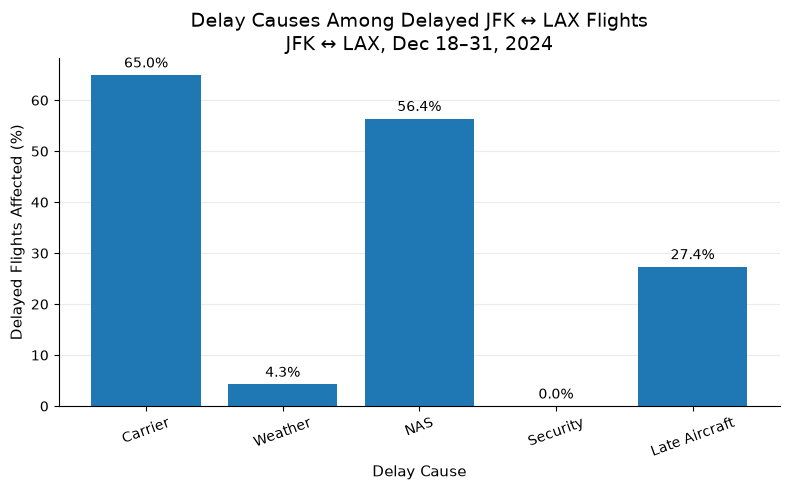

In [588]:
# On what percentage of the 117 delayed flights did this cause appear?
cause_labels = [
    "Carrier",
    "Weather",
    "NAS",
    "Security",
    "Late Aircraft"
]

cause_values = cause_flight_percentages.values

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    cause_labels,
    cause_values
)

ax.set_title("Delay Causes Among Delayed JFK ↔ LAX Flights\n"
              "JFK ↔ LAX, Dec 18–31, 2024")
ax.set_xlabel("Delay Cause")
ax.set_ylabel("Delayed Flights Affected (%)")

ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3
)

plt.xticks(rotation=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

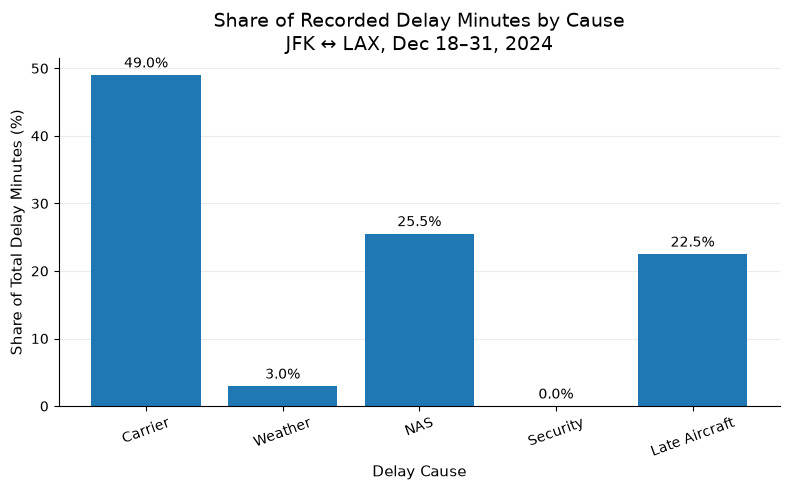

In [589]:
cause_labels = [
    "Carrier",
    "Weather",
    "NAS",
    "Security",
    "Late Aircraft"
]

cause_minute_values = cause_minute_percentages.values

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    cause_labels,
    cause_minute_values
)

ax.set_title(
    "Share of Recorded Delay Minutes by Cause\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)
ax.set_xlabel("Delay Cause")
ax.set_ylabel("Share of Total Delay Minutes (%)")

ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3
)

plt.xticks(rotation=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [590]:
airline_scheduled = (
    holiday_route_df
    .groupby("OP_UNIQUE_CARRIER")
    .size()
)

airline_scheduled

OP_UNIQUE_CARRIER
AA    244
B6    291
DL    219
dtype: int64

In [591]:
airline_on_time = (
    holiday_route_df.loc[on_time_mask]
    .groupby("OP_UNIQUE_CARRIER")
    .size()
)

airline_on_time

OP_UNIQUE_CARRIER
AA    212
B6    251
DL    172
dtype: int64

In [592]:
airline_on_time_rate = (
    airline_on_time / airline_scheduled
) * 100

airline_on_time_rate

OP_UNIQUE_CARRIER
AA    86.885246
B6    86.254296
DL    78.538813
dtype: float64

In [593]:
airline_severe = (
    holiday_route_df.loc[severe_delay_mask]
    .groupby("OP_UNIQUE_CARRIER")
    .size()
)

airline_severe

OP_UNIQUE_CARRIER
AA    19
B6    20
DL    26
dtype: int64

In [594]:
airline_severe_rate = (
    airline_severe / airline_scheduled
) * 100

airline_severe_rate

OP_UNIQUE_CARRIER
AA     7.786885
B6     6.872852
DL    11.872146
dtype: float64

In [595]:
airline_median_delay = (
    holiday_route_df.loc[actually_delayed_mask]
    .groupby("OP_UNIQUE_CARRIER")["ARR_DELAY"]
    .median()
)

airline_median_delay

OP_UNIQUE_CARRIER
AA    61.5
B6    40.5
DL    56.0
Name: ARR_DELAY, dtype: float64

In [596]:
airline_cancellation_rate = (
    holiday_route_df
    .groupby("OP_UNIQUE_CARRIER")["CANCELLED"]
    .mean() * 100
)

airline_cancellation_rate

OP_UNIQUE_CARRIER
AA    0.0
B6    0.0
DL    0.0
Name: CANCELLED, dtype: float64

In [597]:
airline_summary = pd.DataFrame({
    "Scheduled Flights": airline_scheduled,
    "On-Time Rate (%)": airline_on_time_rate,
    "Severe Delay Rate (%)": airline_severe_rate,
    "Cancellation Rate (%)": airline_cancellation_rate,
    "Median Delay When Delayed (min)": airline_median_delay
})

airline_summary

,Scheduled Flights,On-Time Rate (%),Severe Delay Rate (%),Cancellation Rate (%),Median Delay When Delayed (min)
OP_UNIQUE_CARRIER,,,,,
AA,244,86.885246,7.786885,0.0,61.5
B6,291,86.254296,6.872852,0.0,40.5
DL,219,78.538813,11.872146,0.0,56.0


In [598]:
airline_summary = airline_summary.round(2)

airline_summary

,Scheduled Flights,On-Time Rate (%),Severe Delay Rate (%),Cancellation Rate (%),Median Delay When Delayed (min)
OP_UNIQUE_CARRIER,,,,,
AA,244,86.89,7.79,0.0,61.5
B6,291,86.25,6.87,0.0,40.5
DL,219,78.54,11.87,0.0,56.0


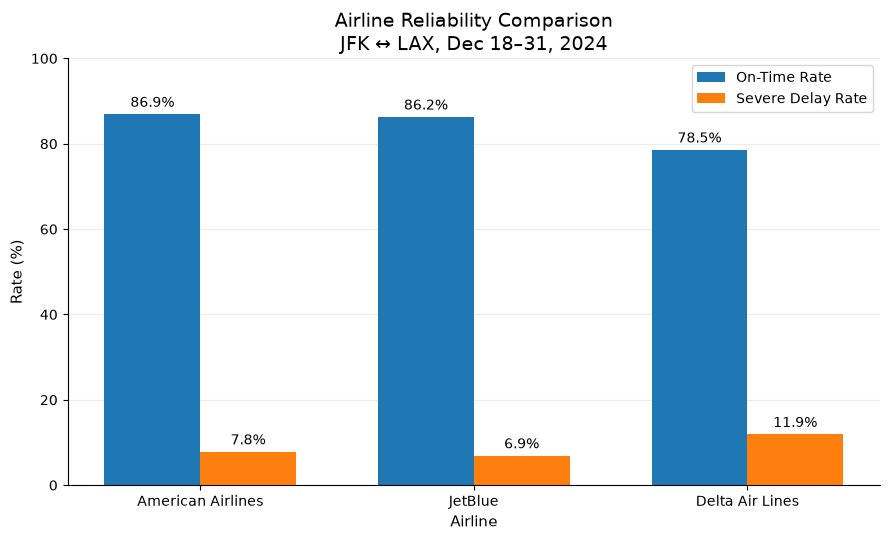

In [599]:
airlines = airline_summary.index.map(airline_name_map)

x = np.arange(len(airlines))
width = 0.35

fig, ax = plt.subplots()

on_time_bars = ax.bar(
    x - width / 2,
    airline_summary["On-Time Rate (%)"],
    width,
    label="On-Time Rate"
)

severe_bars = ax.bar(
    x + width / 2,
    airline_summary["Severe Delay Rate (%)"],
    width,
    label="Severe Delay Rate"
)

ax.set_title(
    "Airline Reliability Comparison\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Airline")
ax.set_ylabel("Rate (%)")

ax.set_xticks(x)
ax.set_xticklabels(airlines)

ax.set_ylim(0, 100)

ax.legend()

ax.bar_label(
    on_time_bars,
    fmt="%.1f%%",
    padding=3
)

ax.bar_label(
    severe_bars,
    fmt="%.1f%%",
    padding=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

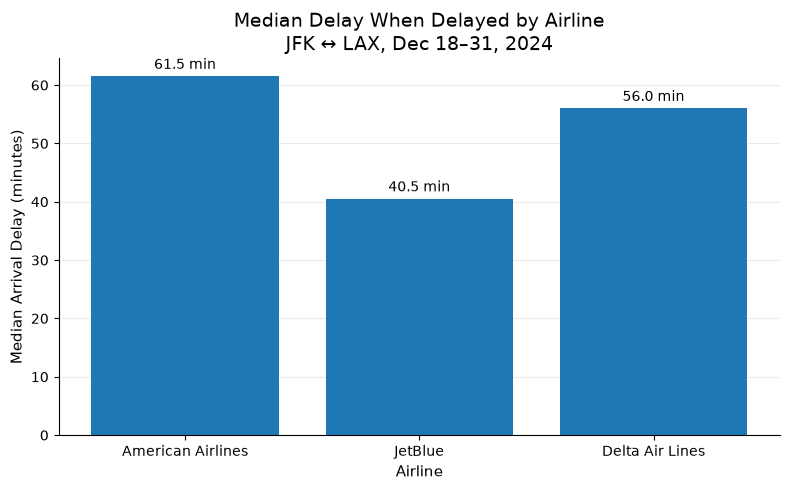

In [600]:
airlines = airline_median_delay.index.map(airline_name_map)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    airlines,
    airline_median_delay.values
)

ax.set_title(
    "Median Delay When Delayed by Airline\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Airline")
ax.set_ylabel("Median Arrival Delay (minutes)")

ax.bar_label(
    bars,
    fmt="%.1f min",
    padding=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [601]:
airline_outcome_pct = (
    pd.crosstab(
        holiday_route_df["OP_UNIQUE_CARRIER"],
        holiday_route_df["FLIGHT_OUTCOME"],
        normalize="index"
    ) * 100
)

airline_outcome_pct

FLIGHT_OUTCOME,Delayed,Diverted,On Time,Severe Delay
OP_UNIQUE_CARRIER,,,,
AA,5.327869,0.000000,86.885246,7.786885
B6,6.872852,0.000000,86.254296,6.872852
DL,8.675799,0.913242,78.538813,11.872146


In [602]:
outcome_order = [
    "On Time",
    "Delayed",
    "Severe Delay",
    "Diverted",
    "Cancelled"
]

airline_outcome_pct = airline_outcome_pct.reindex(
    columns=outcome_order,
    fill_value=0
)

airline_outcome_pct

FLIGHT_OUTCOME,On Time,Delayed,Severe Delay,Diverted,Cancelled
OP_UNIQUE_CARRIER,,,,,
AA,86.885246,5.327869,7.786885,0.000000,0
B6,86.254296,6.872852,6.872852,0.000000,0
DL,78.538813,8.675799,11.872146,0.913242,0


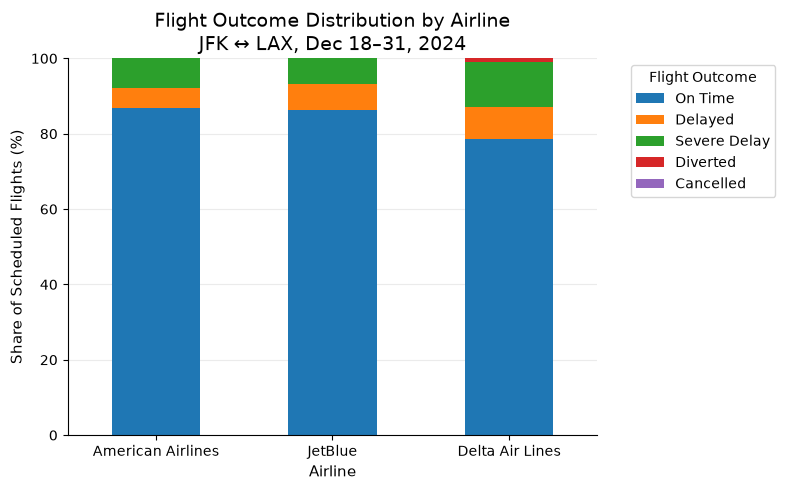

In [624]:
airlines = airline_outcome_pct.index.map(airline_name_map)

fig, ax = plt.subplots(figsize=(8, 5))

airline_outcome_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Flight Outcome Distribution by Airline\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Airline")
ax.set_ylabel("Share of Scheduled Flights (%)")

ax.set_xticklabels(
    airlines,
    rotation=0
)

ax.set_ylim(0, 100)

ax.legend(
    title="Flight Outcome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [604]:
direction_scheduled = (
    holiday_route_df
    .groupby("DIRECTION")
    .size()
)

direction_on_time = (
    holiday_route_df.loc[on_time_mask]
    .groupby("DIRECTION")
    .size()
)

direction_severe = (
    holiday_route_df.loc[severe_delay_mask]
    .groupby("DIRECTION")
    .size()
)

direction_median_delay = (
    holiday_route_df.loc[actually_delayed_mask]
    .groupby("DIRECTION")["ARR_DELAY"]
    .median()
)

In [605]:
direction_on_time_rate = (
    direction_on_time / direction_scheduled
) * 100

direction_severe_rate = (
    direction_severe / direction_scheduled
) * 100

In [606]:
direction_summary = pd.DataFrame({
    "Scheduled Flights": direction_scheduled,
    "On-Time Rate (%)": direction_on_time_rate,
    "Severe Delay Rate (%)": direction_severe_rate,
    "Median Delay When Delayed (min)": direction_median_delay
}).round(2)

direction_summary

,Scheduled Flights,On-Time Rate (%),Severe Delay Rate (%),Median Delay When Delayed (min)
DIRECTION,,,,
JFK → LAX,378,86.51,7.14,51.0
LAX → JFK,376,81.91,10.11,56.0


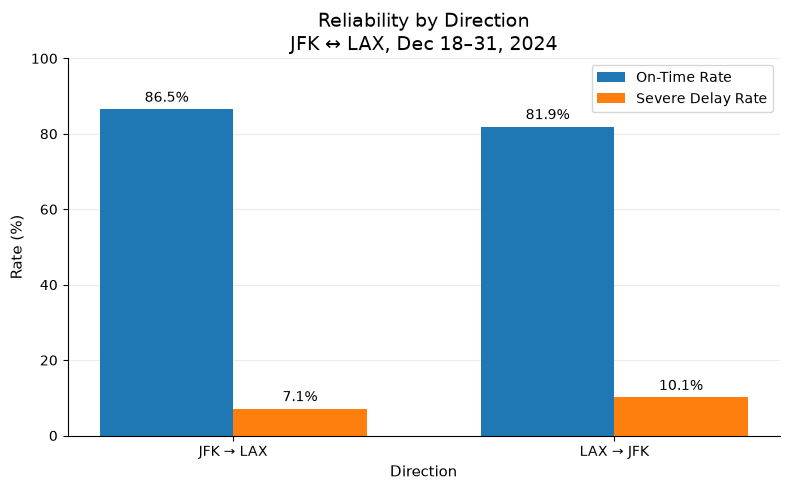

In [607]:
directions = direction_summary.index

x = np.arange(len(directions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

on_time_bars = ax.bar(
    x - width / 2,
    direction_summary["On-Time Rate (%)"],
    width,
    label="On-Time Rate"
)

severe_bars = ax.bar(
    x + width / 2,
    direction_summary["Severe Delay Rate (%)"],
    width,
    label="Severe Delay Rate"
)

ax.set_title(
    "Reliability by Direction\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Direction")
ax.set_ylabel("Rate (%)")

ax.set_xticks(x)
ax.set_xticklabels(directions)

ax.set_ylim(0, 100)
ax.legend()

ax.bar_label(on_time_bars, fmt="%.1f%%", padding=3)
ax.bar_label(severe_bars, fmt="%.1f%%", padding=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

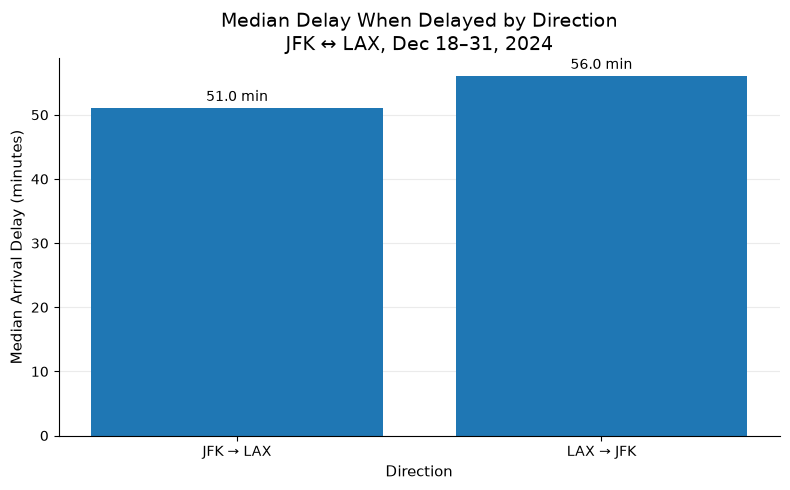

In [608]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    direction_median_delay.index,
    direction_median_delay.values
)

ax.set_title(
    "Median Delay When Delayed by Direction\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Direction")
ax.set_ylabel("Median Arrival Delay (minutes)")

ax.bar_label(
    bars,
    fmt="%.1f min",
    padding=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [609]:
period_scheduled = (
    holiday_route_df
    .groupby("DEPARTURE_PERIOD")
    .size()
)

period_on_time = (
    holiday_route_df.loc[on_time_mask]
    .groupby("DEPARTURE_PERIOD")
    .size()
)

period_severe = (
    holiday_route_df.loc[severe_delay_mask]
    .groupby("DEPARTURE_PERIOD")
    .size()
)

period_median_delay = (
    holiday_route_df.loc[actually_delayed_mask]
    .groupby("DEPARTURE_PERIOD")["ARR_DELAY"]
    .median()
)

In [610]:
period_on_time_rate = (
    period_on_time / period_scheduled
) * 100

period_severe_rate = (
    period_severe / period_scheduled
) * 100

In [611]:
departure_period_summary = pd.DataFrame({
    "Scheduled Flights": period_scheduled,
    "On-Time Rate (%)": period_on_time_rate,
    "Severe Delay Rate (%)": period_severe_rate,
    "Median Delay When Delayed (min)": period_median_delay
}).round(2)

In [612]:
period_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Late Night"
]

departure_period_summary = departure_period_summary.reindex(
    period_order
)

departure_period_summary

,Scheduled Flights,On-Time Rate (%),Severe Delay Rate (%),Median Delay When Delayed (min)
DEPARTURE_PERIOD,,,,
Morning,339,87.61,6.78,52.0
Afternoon,183,83.06,11.48,73.0
Evening,114,83.33,8.77,62.0
Late Night,118,77.12,9.32,30.0


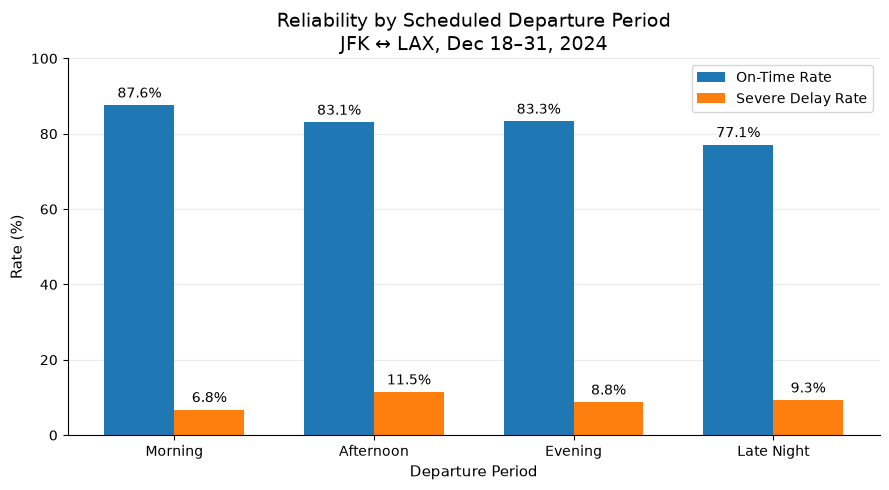

In [613]:
periods = departure_period_summary.index

x = np.arange(len(periods))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

on_time_bars = ax.bar(
    x - width / 2,
    departure_period_summary["On-Time Rate (%)"],
    width,
    label="On-Time Rate"
)

severe_bars = ax.bar(
    x + width / 2,
    departure_period_summary["Severe Delay Rate (%)"],
    width,
    label="Severe Delay Rate"
)

ax.set_title(
    "Reliability by Scheduled Departure Period\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Departure Period")
ax.set_ylabel("Rate (%)")

ax.set_xticks(x)
ax.set_xticklabels(periods)

ax.set_ylim(0, 100)
ax.legend()

ax.bar_label(on_time_bars, fmt="%.1f%%", padding=3)
ax.bar_label(severe_bars, fmt="%.1f%%", padding=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

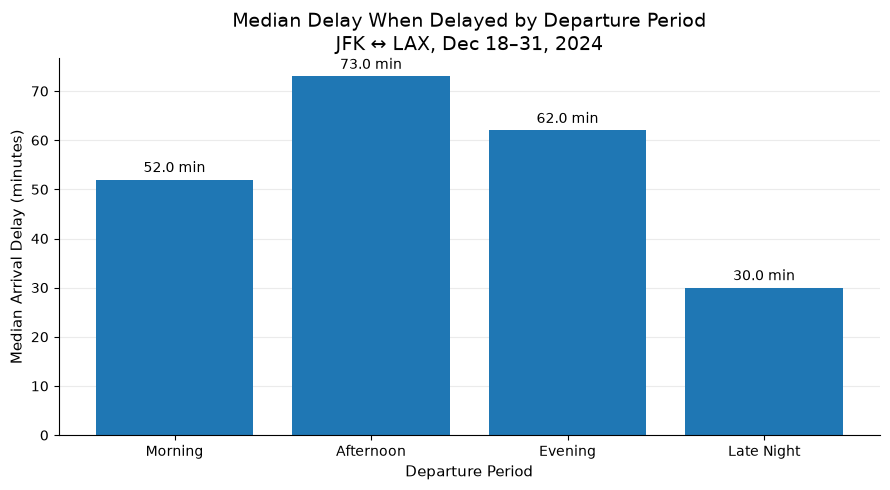

In [614]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    departure_period_summary.index,
    departure_period_summary["Median Delay When Delayed (min)"]
)

ax.set_title(
    "Median Delay When Delayed by Departure Period\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Departure Period")
ax.set_ylabel("Median Arrival Delay (minutes)")

ax.bar_label(
    bars,
    fmt="%.1f min",
    padding=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [615]:
phase_scheduled = (
    holiday_route_df
    .groupby("TRAVEL_PHASE")
    .size()
)

phase_on_time = (
    holiday_route_df.loc[on_time_mask]
    .groupby("TRAVEL_PHASE")
    .size()
)

phase_severe = (
    holiday_route_df.loc[severe_delay_mask]
    .groupby("TRAVEL_PHASE")
    .size()
    .reindex(
        phase_scheduled.index,
        fill_value=0
    )
)

phase_median_delay = (
    holiday_route_df.loc[actually_delayed_mask]
    .groupby("TRAVEL_PHASE")["ARR_DELAY"]
    .median()
)

In [616]:
phase_on_time_rate = (
    phase_on_time / phase_scheduled
) * 100

phase_severe_rate = (
    phase_severe / phase_scheduled
) * 100

In [617]:
travel_phase_summary = pd.DataFrame({
    "Scheduled Flights": phase_scheduled,
    "On-Time Rate (%)": phase_on_time_rate,
    "Severe Delay Rate (%)": phase_severe_rate,
    "Median Delay When Delayed (min)": phase_median_delay
}).round(2)

In [618]:
phase_order = [
    "Outbound Window",
    "Christmas Period",
    "Between Phases",
    "Return Window"
]

travel_phase_summary = travel_phase_summary.reindex(
    phase_order
)

travel_phase_summary

,Scheduled Flights,On-Time Rate (%),Severe Delay Rate (%),Median Delay When Delayed (min)
TRAVEL_PHASE,,,,
Outbound Window,339,80.53,11.50,65.0
Christmas Period,148,85.14,8.78,56.5
Between Phases,162,82.10,8.02,32.0
Return Window,105,98.10,0.00,19.5


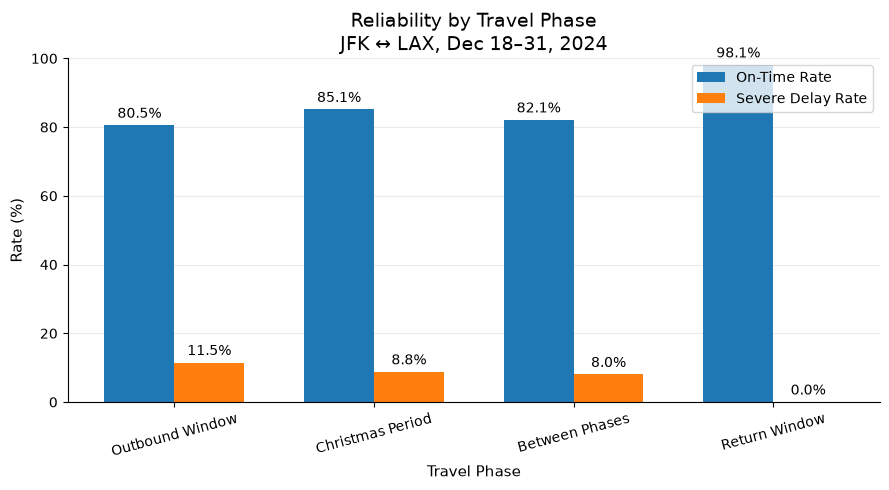

In [619]:
phases = travel_phase_summary.index

x = np.arange(len(phases))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

on_time_bars = ax.bar(
    x - width / 2,
    travel_phase_summary["On-Time Rate (%)"],
    width,
    label="On-Time Rate"
)

severe_bars = ax.bar(
    x + width / 2,
    travel_phase_summary["Severe Delay Rate (%)"],
    width,
    label="Severe Delay Rate"
)

ax.set_title(
    "Reliability by Travel Phase\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Travel Phase")
ax.set_ylabel("Rate (%)")

ax.set_xticks(x)
ax.set_xticklabels(phases)

ax.set_ylim(0, 100)
ax.legend()

ax.bar_label(on_time_bars, fmt="%.1f%%", padding=3)
ax.bar_label(severe_bars, fmt="%.1f%%", padding=3)

plt.xticks(rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

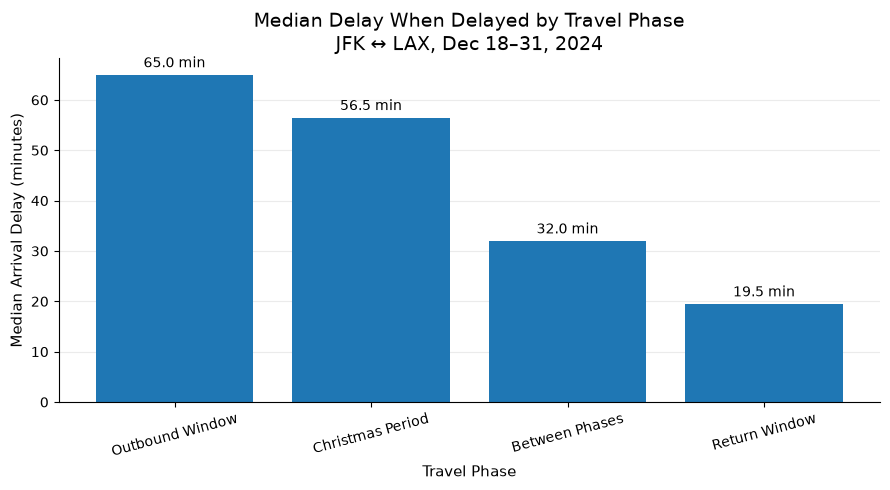

In [620]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    travel_phase_summary.index,
    travel_phase_summary["Median Delay When Delayed (min)"]
)

ax.set_title(
    "Median Delay When Delayed by Travel Phase\n"
    "JFK ↔ LAX, Dec 18–31, 2024"
)

ax.set_xlabel("Travel Phase")
ax.set_ylabel("Median Arrival Delay (minutes)")

ax.bar_label(
    bars,
    fmt="%.1f min",
    padding=3
)

plt.xticks(rotation=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()